In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('london_weather.csv')

In [4]:
df.isnull().sum() 

date                   0
cloud_cover           19
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64

In [5]:
df.shape

(15341, 10)

In [6]:
df

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0
...,...,...,...,...,...,...,...,...,...,...
15336,20201227,1.0,0.9,32.0,7.5,7.5,7.6,2.0,98000.0,NaN
15337,20201228,7.0,3.7,38.0,3.6,1.1,-1.3,0.2,97370.0,NaN
15338,20201229,7.0,0.0,21.0,4.1,2.6,1.1,0.0,98830.0,NaN
15339,20201230,6.0,0.4,22.0,5.6,2.7,-0.1,0.0,100200.0,NaN


In [7]:
print("The percentage of snow_depth rows that has missing values is : ", (1441/15341) * 100 , "%")

The percentage of snow_depth rows that has missing values is :  9.393129522195425 %


In [8]:
# calculating the missing cloumns average temperatures
na = df[df['snow_depth'].isnull()]
not_na = df[df['snow_depth'].notna()]

print(" average mean temperature where the snow depth data was missing: ", na['mean_temp'].mean())
print("average max temperature where the snow depth data was missing: ", na['max_temp'].mean())
print("average min temperature where the snow depth data was missing: ", na['min_temp'].mean())
print(" average mean temperature where the snow depth data was not missing: ", not_na['mean_temp'].mean())
print("average max temperature where the snow depth data was not missing: ", not_na['max_temp'].mean())
print("average min temperature where the snow depth data was not missing: ", not_na['min_temp'].mean())

 average mean temperature where the snow depth data was missing:  15.264044943820224
average max temperature where the snow depth data was missing:  19.60020905923345
average min temperature where the snow depth data was missing:  10.941348158443363
 average mean temperature where the snow depth data was not missing:  11.086859736330235
average max temperature where the snow depth data was not missing:  14.954
average min temperature where the snow depth data was not missing:  7.209798561151079


In [9]:
df['snow_depth'] = df['snow_depth'].fillna(0)
df = df.drop(columns=['date'])
df = df.dropna()

In [10]:
X = df.drop(columns=['precipitation'])
y = df['precipitation']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.1515261103485911

In [14]:
model.intercept_


np.float64(110.72488084686718)

In [15]:
model.coef_ 

array([ 0.14390221, -0.12985106, -0.0011358 , -0.07657731,  0.28200279,
       -0.17532373, -0.00108182, -0.02869254])

In [16]:
# using transformation
Min = X_train.min()
Max = X_train.max()

X_train_s = (X_train - Min) / (Max - Min)
X_test_s = (X_test - Min) / (Max - Min)

model_s = LinearRegression()
model_s.fit(X_train_s, y_train)

y_pred_s = model_s.predict(X_test_s)
r2_s = r2_score(y_test, y_pred_s)

print(f"R2 score after Min max transformation: {r2_s}")

R2 score after Min max transformation: 0.15152611034859054


In [17]:
# second attempt
# second attempt: standardization (z-score)
Mean = X_train.mean()
Std = X_train.std()

X_train_z = (X_train - Mean) / Std
X_test_z = (X_test - Mean) / Std

model_z = LinearRegression()
model_z.fit(X_train_z, y_train)

y_pred_z = model_z.predict(X_test_z)
r2_z = r2_score(y_test, y_pred_z)

print(f"R2 score after Standardization: {r2_z}")

R2 score after Standardization: 0.15152611034859076


In [18]:
X_train.skew()

cloud_cover         -0.693230
sunshine             0.685303
global_radiation     0.650715
max_temp             0.113919
mean_temp           -0.018241
min_temp            -0.173879
pressure            -0.420033
snow_depth          23.626379
dtype: float64

In [19]:
np.log10(101325)

np.float64(5.005716612413731)

In [20]:
max_a = X_train.abs().max()

d = np.ceil(np.log10(max_a))

X_train_d = X_train /(10 ** d)

X_test_d = (X_test / (10 ** d))

model_d = LinearRegression()

model_d.fit(X_train_d, y_train)

y_pred_d = model_d.predict(X_test_d)

r2_d = r2_score(y_test, y_pred_d)

print(f"R2 score after Decimal Scaling: {r2_d}")

R2 score after Decimal Scaling: 0.15152611034859054


In [21]:
# Feature selection
train = X_train_z.copy()
train['precipitation'] = y_train.values
cor = train.corr(method = "pearson")
print(cor)

                  cloud_cover  sunshine  global_radiation  max_temp  \
cloud_cover          1.000000 -0.741968         -0.489568 -0.211073   
sunshine            -0.741968  1.000000          0.852907  0.464768   
global_radiation    -0.489568  0.852907          1.000000  0.687195   
max_temp            -0.211073  0.464768          0.687195  1.000000   
mean_temp           -0.110966  0.389067          0.630869  0.912704   
min_temp             0.049217  0.210618          0.472334  0.811072   
pressure            -0.243999  0.228854          0.154300  0.107686   
snow_depth           0.008111 -0.036012         -0.062836 -0.129633   
precipitation        0.236895 -0.236296         -0.168220 -0.074622   

                  mean_temp  min_temp  pressure  snow_depth  precipitation  
cloud_cover       -0.110966  0.049217 -0.243999    0.008111       0.236895  
sunshine           0.389067  0.210618  0.228854   -0.036012      -0.236296  
global_radiation   0.630869  0.472334  0.154300   -0.06283

Text(0.5, 1.0, 'Pearson Correlation heatmap')

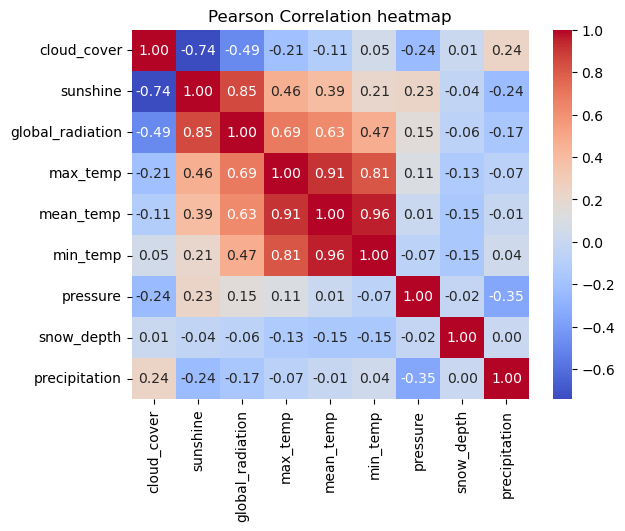

In [22]:
sns.heatmap(cor, annot=True, fmt='.2f', cmap = 'coolwarm')

plt.title('Pearson Correlation heatmap')



In [25]:
dropped = X_train_z.drop(columns=['min_temp', 'max_temp', 'sunshine'])
X_test_d = X_test_z.drop(columns=['min_temp', 'max_temp', 'sunshine'])
model_f = LinearRegression()
model_f.fit(dropped, y_train)
y_pred_f = model_f.predict(X_test_d)
r2_f = r2_score(y_test, y_pred_f)
print(f"R2 after Feature Selection Attempt 1: {r2_f}")


R2 after Feature Selection Attempt 1: 0.1479933677572467


In [26]:
#second attempt
dropped2 = X_train_z.drop(columns=['min_temp', 'max_temp'])
X_test_d2 = X_test_z.drop(columns=['min_temp', 'max_temp'])
model_f2 = LinearRegression()
model_f2.fit(dropped2, y_train)
y_pred_f2 = model_f2.predict(X_test_d2)
r2_f2 = r2_score(y_test, y_pred_f2)
print(f"R2 after Feature Selection Attempt 2: {r2_f2}")

R2 after Feature Selection Attempt 2: 0.14886083816763984


In [27]:
#third attempt 
dropped3 = X_train_z.drop(columns=['min_temp'])
X_test_d3 = X_test_z.drop(columns=['min_temp'])
model_f3 = LinearRegression()
model_f3.fit(dropped3, y_train)
y_pred_f3 = model_f3.predict(X_test_d3)
r2_f3 = r2_score(y_test, y_pred_f3)
print(f"R2 after Feature Selection Attempt 3: {r2_f3}")

R2 after Feature Selection Attempt 3: 0.14908736883927942


In [30]:
dropped3 = X_train_z.drop(columns=['snow_depth'])
X_test_d3 = X_test_z.drop(columns=['snow_depth' ])
model_f3 = LinearRegression()
model_f3.fit(dropped3, y_train)
y_pred_f3 = model_f3.predict(X_test_d3)
r2_f3 = r2_score(y_test, y_pred_f3)
print(f"R2 after Feature Selection Attempt 3: {r2_f3}")

R2 after Feature Selection Attempt 3: 0.15146989917136322


In [32]:
# Outlier Detection Attempt 1 - T=3, m=2
z_scores = (X_train_z - X_train_z.mean()) / X_train_z.std()
outlier = (z_scores.abs() > 3).sum(axis=1) >= 2
X_train_o1 = X_train_z[~outlier]
y_train_o1 = y_train[~outlier]

model_o1 = LinearRegression()
model_o1.fit(X_train_o1, y_train_o1)
r2_o1 = r2_score(y_test, model_o1.predict(X_test_z))
print(f"R2 after Outlier Detection Attempt 1: {r2_o1}")
print(f"Rows removed: {outlier.sum()}")

R2 after Outlier Detection Attempt 1: 0.151570517909003
Rows removed: 7


In [33]:
# Outlier Detection Attempt 2 - T=2.5, m=2
z_scores2 = (X_train_o1 - X_train_o1.mean()) / X_train_o1.std()
outlier2 = (z_scores2.abs() > 2.5).sum(axis=1) >= 2
X_train_o2 = X_train_o1[~outlier2]
y_train_o2 = y_train_o1[~outlier2]

model_o2 = LinearRegression()
model_o2.fit(X_train_o2, y_train_o2)
r2_o2 = r2_score(y_test, model_o2.predict(X_test_z))
print(f"R2 after Outlier Detection Attempt 2: {r2_o2}")
print(f"Rows removed: {outlier2.sum()}")

R2 after Outlier Detection Attempt 2: 0.15132259424611094
Rows removed: 116


In [34]:
# Outlier Detection Attempt 3 - T=3, m=3
z_scores3 = (X_train_o1 - X_train_o1.mean()) / X_train_o1.std()
outlier3 = (z_scores3.abs() > 3).sum(axis=1) >= 3
X_train_o3 = X_train_o1[~outlier3]
y_train_o3 = y_train_o1[~outlier3]

model_o3 = LinearRegression()
model_o3.fit(X_train_o3, y_train_o3)
r2_o3 = r2_score(y_test, model_o3.predict(X_test_z))
print(f"R2 after Outlier Detection Attempt 3: {r2_o3}")
print(f"Rows removed: {outlier3.sum()}")

R2 after Outlier Detection Attempt 3: 0.151570517909003
Rows removed: 0
